In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Настройки для красивых графиков
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

print("✅ Библиотеки загружены")

✅ Библиотеки загружены


In [3]:
# Путь к главной папке (Data_Analyst_Portfolio)
base_path = "/Users/anastasialeonteva/Data_Analyst_Portfolio"

# Путь к сырым данным для проекта 1
raw_path = f"{base_path}/01_RFM_Sales_Analysis/data/raw"

# Загружаем файлы
df_orders = pd.read_csv(f"{raw_path}/orders.csv")
df_payments = pd.read_csv(f"{raw_path}/payments.csv")
df_customers = pd.read_csv(f"{raw_path}/customers.csv")

print("✅ Файлы загружены")
print(f"Заказы: {df_orders.shape}")
print(f"Платежи: {df_payments.shape}")
print(f"Клиенты: {df_customers.shape}")

✅ Файлы загружены
Заказы: (99441, 8)
Платежи: (103886, 5)
Клиенты: (99441, 5)


In [4]:
print("=== ЗАКАЗЫ ===")
print(df_orders.head(2))
print("\n=== ПЛАТЕЖИ ===")
print(df_payments.head(2))
print("\n=== КЛИЕНТЫ ===")
print(df_customers.head(2))

=== ЗАКАЗЫ ===
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  

=== ПЛАТЕЖИ ===
                           order_id  payment_sequential payment_type  \
0  b81ef226f3fe1789b1e8b2acac839d17                   1  credit_card   
1  a9810da82917af2d9aefd1278f1dcfa0                   1  credit_card   

   payment_installments  payment_value  
0 

In [5]:
# Шаг 1: Объединяем заказы с платежами по order_id
df_merged = df_orders.merge(df_payments, on='order_id', how='inner')

# Шаг 2: Добавляем клиентов по customer_id
df_merged = df_merged.merge(df_customers, on='customer_id', how='inner')

print(f"Объединённая таблица: {df_merged.shape}")
print(f"Колонки: {df_merged.columns.tolist()}")

Объединённая таблица: (103886, 16)
Колонки: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


In [6]:
# Выбираем колонки для RFM-анализа
df_rfm = df_merged[['customer_unique_id', 'order_purchase_timestamp', 'payment_value']].copy()

# Переименовываем для удобства
df_rfm.columns = ['customer_id', 'purchase_date', 'amount']

print(df_rfm.head())

                        customer_id        purchase_date  amount
0  7c396fd4830fd04220f754e42b4e5bff  2017-10-02 10:56:33   18.12
1  7c396fd4830fd04220f754e42b4e5bff  2017-10-02 10:56:33    2.00
2  7c396fd4830fd04220f754e42b4e5bff  2017-10-02 10:56:33   18.59
3  af07308b275d755c9edb36a90c618231  2018-07-24 20:41:37  141.46
4  3a653a41f6f9fc3d2a113cf8398680e8  2018-08-08 08:38:49  179.12


In [7]:
# Преобразуем в datetime
df_rfm['purchase_date'] = pd.to_datetime(df_rfm['purchase_date'])

# Проверяем
print(f"Тип данных: {df_rfm['purchase_date'].dtype}")
print(f"Диапазон дат: с {df_rfm['purchase_date'].min()} по {df_rfm['purchase_date'].max()}")

Тип данных: datetime64[ns]
Диапазон дат: с 2016-09-04 21:15:19 по 2018-10-17 17:30:18


In [8]:
# Удаляем отрицательные суммы
df_rfm = df_rfm[df_rfm['amount'] > 0]

# Удаляем дубликаты
df_rfm = df_rfm.drop_duplicates()

# Удаляем пустые даты
df_rfm = df_rfm.dropna(subset=['purchase_date'])

print(f"После чистки: {df_rfm.shape}")
print(df_rfm.head())

После чистки: (103222, 3)
                        customer_id       purchase_date  amount
0  7c396fd4830fd04220f754e42b4e5bff 2017-10-02 10:56:33   18.12
1  7c396fd4830fd04220f754e42b4e5bff 2017-10-02 10:56:33    2.00
2  7c396fd4830fd04220f754e42b4e5bff 2017-10-02 10:56:33   18.59
3  af07308b275d755c9edb36a90c618231 2018-07-24 20:41:37  141.46
4  3a653a41f6f9fc3d2a113cf8398680e8 2018-08-08 08:38:49  179.12


In [9]:
# Создаём папку processed, если её нет
import os
processed_path = f"{base_path}/01_RFM_Sales_Analysis/data/processed"
os.makedirs(processed_path, exist_ok=True)

# Сохраняем
df_rfm.to_csv(f"{processed_path}/rfm_ready.csv", index=False)
print(f"✅ Данные сохранены в {processed_path}/rfm_ready.csv")

✅ Данные сохранены в /Users/anastasialeonteva/Data_Analyst_Portfolio/01_RFM_Sales_Analysis/data/processed/rfm_ready.csv


In [10]:
# Берём последнюю дату в данных + 1 день как "сегодня"
snapshot_date = df_rfm['purchase_date'].max() + timedelta(days=1)

print(f"Последняя покупка в данных: {df_rfm['purchase_date'].max().date()}")
print(f"Дата анализа ('сегодня'): {snapshot_date.date()}")

Последняя покупка в данных: 2018-10-17
Дата анализа ('сегодня'): 2018-10-18


In [11]:
rfm_table = df_rfm.groupby('customer_id').agg({
    'purchase_date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'customer_id': 'count',  # Frequency
    'amount': 'sum'  # Monetary
}).rename(columns={
    'purchase_date': 'Recency',
    'customer_id': 'Frequency',
    'amount': 'Monetary'
})

print(f"Количество уникальных клиентов: {len(rfm_table)}")
print("\nПервые 5 клиентов:")
print(rfm_table.head())

Количество уникальных клиентов: 96093

Первые 5 клиентов:
                                  Recency  Frequency  Monetary
customer_id                                                   
0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90
0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19
0000f46a3911fa3c0805444483337064      586          1     86.22
0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62
0004aac84e0df4da2b147fca70cf8255      337          1    196.89


In [12]:
print("Статистика по RFM-метрикам:")
print(rfm_table.describe())

Статистика по RFM-метрикам:
            Recency     Frequency      Monetary
count  96093.000000  96093.000000  96093.000000
mean     288.735912      1.074189    166.370093
std      153.405290      0.390620    231.249061
min        1.000000      1.000000      6.180000
25%      164.000000      1.000000     63.010000
50%      269.000000      1.000000    107.900000
75%      398.000000      1.000000    183.300000
max      773.000000     24.000000  13664.080000


In [13]:
rfm_table = df_rfm.groupby('customer_id').agg({
    'purchase_date': lambda x: (snapshot_date - x.max()).days,  # Recency
    'customer_id': 'count',  # Frequency
    'amount': 'sum'  # Monetary
}).rename(columns={
    'purchase_date': 'Recency',
    'customer_id': 'Frequency',
    'amount': 'Monetary'
})

print(f"Количество уникальных клиентов: {len(rfm_table)}")
print("\nПервые 5 клиентов:")
print(rfm_table.head())

Количество уникальных клиентов: 96093

Первые 5 клиентов:
                                  Recency  Frequency  Monetary
customer_id                                                   
0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90
0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19
0000f46a3911fa3c0805444483337064      586          1     86.22
0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62
0004aac84e0df4da2b147fca70cf8255      337          1    196.89


In [14]:
print("Статистика по RFM-метрикам:")
print(rfm_table.describe())

Статистика по RFM-метрикам:
            Recency     Frequency      Monetary
count  96093.000000  96093.000000  96093.000000
mean     288.735912      1.074189    166.370093
std      153.405290      0.390620    231.249061
min        1.000000      1.000000      6.180000
25%      164.000000      1.000000     63.010000
50%      269.000000      1.000000    107.900000
75%      398.000000      1.000000    183.300000
max      773.000000     24.000000  13664.080000


In [15]:
# Создаём ранги (1 — лучший, 4 — худший)
rfm_table['R_rank'] = pd.qcut(rfm_table['Recency'], 4, labels=['4', '3', '2', '1'])
rfm_table['F_rank'] = pd.qcut(rfm_table['Frequency'].rank(method='first'), 4, labels=['1', '2', '3', '4'])
rfm_table['M_rank'] = pd.qcut(rfm_table['Monetary'], 4, labels=['1', '2', '3', '4'])

# RFM-скор (объединяем три цифры)
rfm_table['RFM_Score'] = rfm_table['R_rank'].astype(str) + rfm_table['F_rank'].astype(str) + rfm_table['M_rank'].astype(str)

print(rfm_table[['Recency', 'Frequency', 'Monetary', 'R_rank', 'F_rank', 'M_rank', 'RFM_Score']].head(10))

                                  Recency  Frequency  Monetary R_rank F_rank  \
customer_id                                                                    
0000366f3b9a7992bf8c76cfdf3221e2      161          1    141.90      4      1   
0000b849f77a49e4a4ce2b2a4ca5be3f      164          1     27.19      4      1   
0000f46a3911fa3c0805444483337064      586          1     86.22      1      1   
0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62      2      1   
0004aac84e0df4da2b147fca70cf8255      337          1    196.89      2      1   
0004bd2a26a76fe21f786e4fbd80607f      195          1    166.98      3      1   
00050ab1314c0e55a6ca13cf7181fecf      181          1     35.38      3      1   
00053a61a98854899e70ed204dd4bafe      232          1    419.18      3      1   
0005e1862207bf6ccc02e4228effd9a0      592          1    150.12      1      1   
0005ef4cd20d2893f0d9fbd94d3c0d97      220          1    129.76      3      1   

                                 M_rank

In [16]:
# Функция для определения сегмента
def segment_customer(row):
    # Золотые: недавно, часто, много денег
    if row['R_rank'] in ['1', '2'] and row['F_rank'] in ['3', '4'] and row['M_rank'] in ['3', '4']:
        return 'Champions (Gold)'
    # Лояльные: недавно, средне, средне
    elif row['R_rank'] in ['1', '2'] and row['F_rank'] in ['2', '3'] and row['M_rank'] in ['2', '3']:
        return 'Loyal Customers'
    # Новые: недавно, но мало заказов
    elif row['R_rank'] in ['1', '2'] and row['F_rank'] in ['1', '2'] and row['M_rank'] in ['1', '2']:
        return 'New Customers'
    # Спящие: давно не покупали, но раньше покупали
    elif row['R_rank'] in ['3', '4'] and row['F_rank'] in ['3', '4']:
        return 'Hibernating'
    # Потерянные: давно и мало заказов
    elif row['R_rank'] in ['3', '4'] and row['F_rank'] in ['1', '2']:
        return 'Lost'
    else:
        return 'Regular'

rfm_table['Segment'] = rfm_table.apply(segment_customer, axis=1)

print("Распределение по сегментам:")
print(rfm_table['Segment'].value_counts())

Распределение по сегментам:
Segment
Lost                24060
Hibernating         24013
Regular             17556
Champions (Gold)    11928
Loyal Customers      9290
New Customers        9246
Name: count, dtype: int64


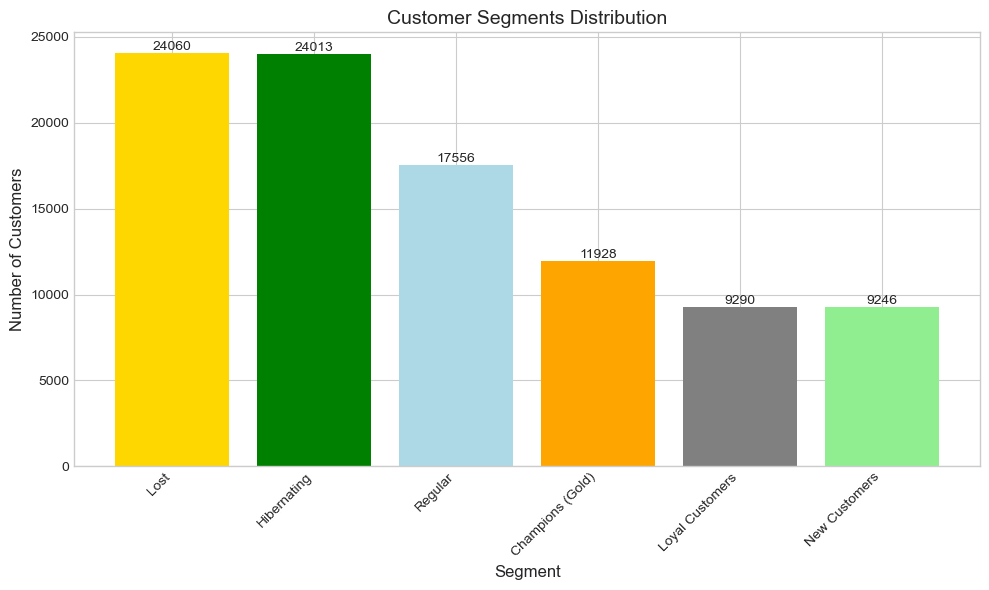

In [17]:
plt.figure(figsize=(10, 6))
segment_counts = rfm_table['Segment'].value_counts()
colors = ['gold', 'green', 'lightblue', 'orange', 'gray', 'lightgreen']
bars = plt.bar(segment_counts.index, segment_counts.values, color=colors[:len(segment_counts)])
plt.title('Customer Segments Distribution', fontsize=14)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Добавляем цифры на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5, f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(f"{base_path}/01_RFM_Sales_Analysis/outputs/segment_distribution.png", dpi=100)
plt.show()

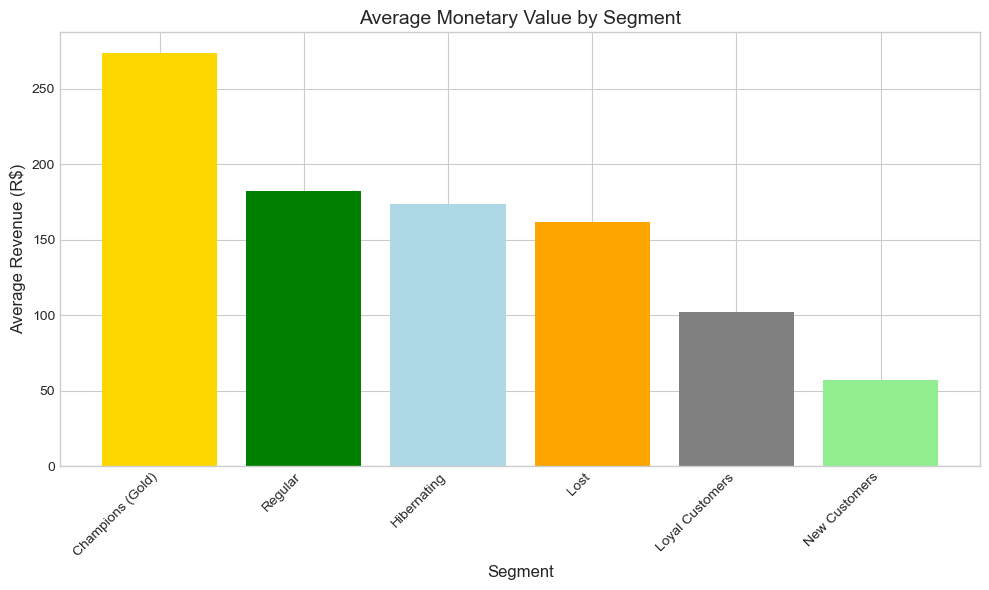

In [18]:
plt.figure(figsize=(10, 6))
segment_monetary = rfm_table.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
colors_monetary = ['gold', 'green', 'lightblue', 'orange', 'gray', 'lightgreen']
plt.bar(segment_monetary.index, segment_monetary.values, color=colors_monetary[:len(segment_monetary)])
plt.title('Average Monetary Value by Segment', fontsize=14)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Average Revenue (R$)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{base_path}/01_RFM_Sales_Analysis/outputs/monetary_by_segment.png", dpi=100)
plt.show()

In [19]:
# Сохраняем таблицу с сегментами
rfm_table.to_csv(f"{base_path}/01_RFM_Sales_Analysis/data/processed/rfm_segments.csv")

print("✅ RFM-таблица с сегментами сохранена")
print(f"Всего клиентов: {len(rfm_table)}")
print(f"\nТоп-5 клиентов по Monetary:")
print(rfm_table.nlargest(5, 'Monetary')[['Recency', 'Frequency', 'Monetary', 'Segment']])

✅ RFM-таблица с сегментами сохранена
Всего клиентов: 96093

Топ-5 клиентов по Monetary:
                                  Recency  Frequency  Monetary  \
customer_id                                                      
0a0a92112bd4c708ca5fde585afaa872      384          1  13664.08   
46450c74a0d8c5ca9395da1daac6c120       61          3   9553.02   
da122df9eeddfedc1dc1f5349a1a690c      565          2   7571.63   
763c8b1c9c68a0229c42c9fc6f662b93       95          1   7274.88   
dc4802a71eae9be1dd28f5d788ceb526      612          1   6929.31   

                                           Segment  
customer_id                                         
0a0a92112bd4c708ca5fde585afaa872           Regular  
46450c74a0d8c5ca9395da1daac6c120       Hibernating  
da122df9eeddfedc1dc1f5349a1a690c  Champions (Gold)  
763c8b1c9c68a0229c42c9fc6f662b93              Lost  
dc4802a71eae9be1dd28f5d788ceb526  Champions (Gold)  
